In [1]:
import pandas as pd
import os
import random
import chardet
import requests
import json
import numpy as np
from urllib3.util.retry import Retry
import openai
from requests.adapters import HTTPAdapter
import os
import pickle
import matplotlib.pyplot as plt
# from utils.read_group_danmu import read_group_danmu

In [2]:
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-FullMovies\Emotion_scores\scores_allMovies_resample.pkl', 'rb') as f:
    scores_dict = pickle.load(f)
# del scores_dict['BV1zW411d7Rb']
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-FullMovies\Emotion_scores\times_allMovies_resample.pkl', 'rb') as f:
    time_dict= pickle.load(f)
# del time_dict['BV1zW411d7Rb']

print(len(scores_dict.keys()))
print(len(time_dict.keys()))

102
102


In [3]:
scores_all = np.zeros((0,6))
n_samples = []

scores_key = list(scores_dict.keys())
count = 0
for key in scores_key:
    print(scores_dict[key].shape)
    scores_all = np.concatenate((scores_all, scores_dict[key]), 0)
    n_samples.append(scores_dict[key].shape[0])
    count += 1
print(scores_all.shape)
n_samples_cum = np.concatenate((np.array([0]), np.cumsum(n_samples)))
print(n_samples_cum[-5:])

(4565, 6)
(3699, 6)
(4218, 6)
(1158, 6)
(3955, 6)
(3907, 6)
(4714, 6)
(3192, 6)
(2984, 6)
(3800, 6)
(3051, 6)
(3007, 6)
(4277, 6)
(5197, 6)
(3371, 6)
(3058, 6)
(3692, 6)
(3824, 6)
(3642, 6)
(3513, 6)
(6846, 6)
(2616, 6)
(2717, 6)
(3223, 6)
(3500, 6)
(4148, 6)
(3174, 6)
(3960, 6)
(3516, 6)
(3088, 6)
(4303, 6)
(2692, 6)
(4010, 6)
(2179, 6)
(2700, 6)
(4200, 6)
(3530, 6)
(3611, 6)
(3210, 6)
(4031, 6)
(3293, 6)
(4606, 6)
(5233, 6)
(3487, 6)
(4200, 6)
(3405, 6)
(4484, 6)
(3562, 6)
(3987, 6)
(4766, 6)
(3337, 6)
(2703, 6)
(2995, 6)
(2522, 6)
(4044, 6)
(3547, 6)
(3019, 6)
(2789, 6)
(1396, 6)
(3753, 6)
(3557, 6)
(4445, 6)
(5073, 6)
(3361, 6)
(3299, 6)
(3914, 6)
(2651, 6)
(2634, 6)
(3734, 6)
(3296, 6)
(5312, 6)
(4252, 6)
(2729, 6)
(2721, 6)
(3117, 6)
(2910, 6)
(4223, 6)
(2703, 6)
(3214, 6)
(3854, 6)
(3990, 6)
(3631, 6)
(3372, 6)
(2874, 6)
(3032, 6)
(2207, 6)
(3129, 6)
(2081, 6)
(2788, 6)
(2601, 6)
(4910, 6)
(3071, 6)
(1895, 6)
(4002, 6)
(4031, 6)
(3191, 6)
(2957, 6)
(3355, 6)
(2830, 6)
(3452, 6)


Explained variance ratio: [0.49378133 0.19681466 0.16693501 0.08574263 0.03698317 0.01974321]


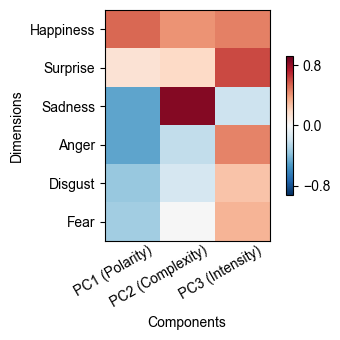

In [4]:
from sklearn.decomposition import PCA
import matplotlib
emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(preds_all)

pca = PCA(n_components=6)

X_pca = pca.fit_transform(scores_all)

print("Explained variance ratio:", pca.explained_variance_ratio_)

pca.components_[[3,4],:] = -pca.components_[[3,4],:]

matplotlib.rcParams['font.size'] = 10
matplotlib.rcParams['font.family'] = 'Arial'
fig, ax = plt.subplots(figsize=(4,3.5))
cax = ax.imshow(pca.components_.transpose()[:,:3],cmap='RdBu_r')
ax.set_aspect(0.7)
plt.xticks(np.arange(0.4,3.4,1),['PC1 (Polarity)', 'PC2 (Complexity)', 'PC3 (Intensity)'], rotation=30, ha='right')
plt.gca().tick_params(axis='x', pad=2)
plt.tick_params(axis='x', length=0)
plt.yticks(np.arange(6), emos)
plt.xlabel('Components')
plt.ylabel('Dimensions')
cbar = plt.colorbar(cax, shrink=0.6)
cbar.set_ticks([-0.8, 0.0, 0.8])
# max_lim = np.maximum(np.nanmax(pca.components_), -np.nanmin(pca.components_))
cax.set_clim([-0.921, 0.921])
# print(max_lim)
plt.tight_layout()
# plt.savefig('figures/pca_scores_danmu_all_PC3.svg', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Circle, FancyArrowPatch
from scipy.ndimage import gaussian_filter
from sklearn.decomposition import PCA
from sklearn.neighbors import KernelDensity

def _scott_bandwidth(X2):
    X2 = np.asarray(X2, float); n, d = X2.shape
    s = X2.std(axis=0, ddof=1).mean()
    return s * n ** (-1.0 / (d + 4))

def _hdr_thresholds(dens_grid, levels=(0.5, 0.8, 0.95), cell_area=1.0):
    f = dens_grid.ravel()
    idx = np.argsort(f)[::-1]
    mass = np.cumsum(f[idx]) * cell_area
    total = mass[-1]
    thr = []
    for a in levels:
        k = np.searchsorted(mass, a*total)
        k = min(max(k, 0), len(f)-1)
        thr.append(float(f[idx[k]]))
    return sorted(thr)

def _kde_on_grid(X2, xs, ys, bandwidth):
    XX, YY = np.meshgrid(xs, ys)
    grid = np.c_[XX.ravel(), YY.ravel()]
    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth)
    kde.fit(X2)
    logd = kde.score_samples(grid)
    dens = np.exp(logd).reshape(XX.shape)
    return XX, YY, dens

def _global_assign_and_transition(scores_all, centers6, n_samples_cum, eps=1e-6):
    X = np.asarray(scores_all, float)
    dif = X[:, None, :] - centers6[None, :, :]
    d2 = np.sum(dif*dif, axis=2)
    labels = d2.argmin(axis=1).astype(int)  # 0..5

    K = 6
    C = np.zeros((K, K), float)
    M = len(n_samples_cum) - 1
    for m in range(M):
        s, e = int(n_samples_cum[m]), int(n_samples_cum[m+1])
        if e - s <= 1: continue
        seg = labels[s:e]
        for a, b in zip(seg[:-1], seg[1:]):
            C[a, b] += 1.0
    P = C + eps
    P = P / P.sum(axis=1, keepdims=True)
    pi = (P.sum(axis=0) + eps)
    pi = pi / pi.sum()
    return labels, P, pi

def fit_six_emotion_anchors(
    scores_all, topk_frac=0.20, eps=1e-6
):

    X = np.asarray(scores_all, float)
    N, D = X.shape
    assert D == 6

    sums = X.sum(axis=1, keepdims=True) + eps
    purity = X / sums  
    centers = np.zeros((6, D), float)
    covs = np.zeros((6, D, D), float)
    counts = np.zeros(6, int)

    for k in range(6):
        mask = (X.argmax(axis=1) == k)
        Xk = X[mask]
        # if len(Xk) < min_n:
        #     idx = np.argsort(purity[:, k])[::-1]
        #     take = max(min_n, int(topk_frac * N))
        #     Xk = X[idx[:take]]

        m = len(Xk)
        # print(int(topk_frac * m))
        kk = int(topk_frac * m)
        idx2 = np.argsort(Xk[:, k])[::-1][:kk]
        Xk2 = Xk[idx2]

        centers[k] = Xk2.mean(axis=0)
        C = np.cov(Xk2, rowvar=False)
        C = 0.5*(C + C.T) + 1e-9*np.eye(D)
        covs[k] = C
        counts[k] = len(Xk2)
    return centers, covs, counts

EMO_NAMES  = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]
EMO_COLORS = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']

In [6]:
centers6, covs6, counts = fit_six_emotion_anchors(
    scores_all,        # (N, 6)
    # purity_tau=1.0,   
    topk_frac=0.50 
    # min_n=500         
)
print("anchors per emotion:", counts)

anchors per emotion: [112913  37849  12221  13095    787   1218]


In [7]:
random_state = 0
grid_res=400
bandwidth=None
bandwidth_scale=1.0
glow_sigma=6.0
levels=(0.5, 0.8, 0.95, 0.99)
    
rng = np.random.default_rng(random_state)

# 1) PCA(2) on pooled data
pca = PCA(n_components=2, svd_solver="full", random_state=random_state)
X2 = pca.fit_transform(scores_all)
C2 = pca.transform(centers6)  

# 3) KDE on a shared grid
pad = 0.01
xmin, xmax = X2[:,0].min(), X2[:,0].max()
ymin, ymax = X2[:,1].min(), X2[:,1].max()
dx, dy = xmax - xmin, ymax - ymin
xmin -= pad*dx; xmax = xmax+pad*dx+0.06; ymin -= pad*dy; ymax += pad*dy

xs = np.linspace(xmin, xmax, grid_res)
ys = np.linspace(ymin, ymax, grid_res)
cell_area = (xs[1]-xs[0]) * (ys[1]-ys[0])

if bandwidth is None:
    bandwidth = _scott_bandwidth(X2) * float(bandwidth_scale)

# XX, YY, dens = _kde_on_grid(X2, xs, ys, bandwidth)
# dens_blur = gaussian_filter(dens, sigma=glow_sigma)
# thr = _hdr_thresholds(dens, levels=levels, cell_area=cell_area)


In [8]:
with open('kde_prep2.pkl', 'rb') as f:
    kde_prep = pickle.load(f)
XX, YY, dens, dens_blur, thr = kde_prep['XX'], kde_prep['YY'], kde_prep['dens'], kde_prep['dens_blur'], kde_prep['thr']

In [9]:
print(xmin, xmax, ymin, ymax)
print(np.min(XX), np.max(XX), np.min(YY), np.max(YY))
xmin, xmax, ymin, ymax = np.min(XX), np.max(XX), np.min(YY), np.max(YY)

-9.375047871028144 4.643644358322811 -5.303414152688677 6.301404531999867
-10.059297490113975 5.267893977408642 -5.872277813702821 6.870268193014011


In [12]:
# ============================================================
# Density-defined regions in PC1-PC2 emotion space
# ============================================================

import numpy as np
import pandas as pd
from scipy import stats
from scipy.interpolate import RegularGridInterpolator
from statsmodels.stats.multitest import multipletests


# ------------------------------------------------------------
# 1. HDR thresholds
# ------------------------------------------------------------

def hdr_thresholds_by_mass(
    dens_grid,
    levels=(0.25, 0.50, 0.75),
    cell_area=1.0
):
    """
    Return KDE density thresholds corresponding to HDR probability masses.

    Example
    -------
    thresholds[0.25] = density cutoff enclosing the highest-density 25% mass
    thresholds[0.50] = cutoff enclosing 50% mass
    thresholds[0.75] = cutoff enclosing 75% mass

    Note:
    threshold_25 > threshold_50 > threshold_75
    """

    f = np.asarray(dens_grid, float).ravel()

    order = np.argsort(f)[::-1]
    f_sorted = f[order]

    cumulative_mass = np.cumsum(f_sorted) * cell_area
    total_mass = cumulative_mass[-1]

    thresholds = {}

    for level in levels:

        idx = np.searchsorted(
            cumulative_mass,
            level * total_mass,
            side="left"
        )

        idx = np.clip(
            idx,
            0,
            len(f_sorted) - 1
        )

        thresholds[level] = float(
            f_sorted[idx]
        )

    return thresholds


# ------------------------------------------------------------
# 2. Calculate HDR thresholds
# ------------------------------------------------------------

HDR_LEVELS = (0.25, 0.50, 0.75)

hdr_thresholds = hdr_thresholds_by_mass(
    dens,
    levels=HDR_LEVELS,
    cell_area=cell_area
)

thr25 = hdr_thresholds[0.25]
thr50 = hdr_thresholds[0.50]
thr75 = hdr_thresholds[0.75]

print("HDR thresholds:")
print(f"25% HDR: {thr25:.6g}")
print(f"50% HDR: {thr50:.6g}")
print(f"75% HDR: {thr75:.6g}")

assert thr25 >= thr50 >= thr75


# ------------------------------------------------------------
# 3. Evaluate KDE density at each observed time point
#
# dens has shape (len(ys), len(xs)).
# RegularGridInterpolator therefore takes coordinates as (y, x).
# ------------------------------------------------------------

density_interp = RegularGridInterpolator(
    (ys, xs),
    dens,
    method="linear",
    bounds_error=False,
    fill_value=np.nan
)

point_density = density_interp(
    np.column_stack([
        X2[:, 1],
        X2[:, 0]
    ])
)


# ------------------------------------------------------------
# 4. Assign density-defined regions
#
# Q1 = inside 25% HDR, highest density
# Q2 = 25-50% HDR shell
# Q3 = 50-75% HDR shell
# Q4 = outside 75% HDR, peripheral / lowest density
# ------------------------------------------------------------

REGION_ORDER = [
    "Q1",
    "Q2",
    "Q3",
    "Q4"
]

region_all = np.full(
    len(X2),
    "Q4",
    dtype=object
)

region_all[
    point_density >= thr75
] = "Q3"

region_all[
    point_density >= thr50
] = "Q2"

region_all[
    point_density >= thr25
] = "Q1"


# ------------------------------------------------------------
# 5. Inspect region sizes
# ------------------------------------------------------------

region_counts = pd.Series(
    region_all
).value_counts().reindex(
    REGION_ORDER
)

region_fraction = (
    region_counts /
    region_counts.sum()
)

print("\nObserved points in density-defined regions:")
for q in REGION_ORDER:
    print(
        f"{q}: "
        f"{region_counts[q]:,} points "
        f"({100 * region_fraction[q]:.2f}%)"
    )

HDR thresholds:
25% HDR: 0.087158
50% HDR: 0.0499571
75% HDR: 0.019157

Observed points in density-defined regions:
Q1: 76,336 points (21.43%)
Q2: 81,515 points (22.89%)
Q3: 90,335 points (25.36%)
Q4: 107,982 points (30.32%)


In [ ]:
# levels=(0.25, 0.5, 0.75)
# thr = _hdr_thresholds(dens, levels=levels, cell_area=cell_area)
# print(thr)

[0.01915704568142476, 0.04995705599878718, 0.08715797072702591]


In [22]:
movie_keys = list(scores_dict.keys())
DT = 2.0

# ============================================================
# Point-level metrics
# ============================================================

def top2_margin(scores):
    """
    Difference between largest and second-largest
    emotion ratings at each time point.
    """
    Xs = np.sort(
        np.asarray(scores, float),
        axis=1
    )

    return (
        Xs[:, -1] -
        Xs[:, -2]
    )


# ------------------------------------------------------------
# Mean activation
# ------------------------------------------------------------

mean_activation = np.mean(
    scores_all,
    axis=1
)


# ------------------------------------------------------------
# Top-2 margin
# Smaller = more blending
# ------------------------------------------------------------

margin12 = top2_margin(
    scores_all
)


# ------------------------------------------------------------
# Speed in PC1-PC2 space
#
# Speed is attached to the starting point of each step.
# The final point of each movie has no outgoing step -> NaN.
# ------------------------------------------------------------

speed_pc_per_s = np.full(
    len(X2),
    np.nan,
    dtype=float
)

for movie_idx in range(
    len(movie_keys)
):

    s = int(
        n_samples_cum[movie_idx]
    )

    e = int(
        n_samples_cum[movie_idx + 1]
    )

    if e - s <= 1:
        continue

    displacement = np.linalg.norm(
        np.diff(
            X2[s:e],
            axis=0
        ),
        axis=1
    )

    speed_pc_per_s[
        s:e - 1
    ] = displacement / DT

In [23]:
from pathlib import Path

FIG_DIR = Path('figures')

# ============================================================
# Unified point-level DataFrame
# ============================================================

movie_index_all = np.repeat(
    np.arange(
        len(movie_keys)
    ),
    n_samples
)

point_index_all = np.concatenate([
    np.arange(n)
    for n in n_samples
])


point_metrics_density_df = pd.DataFrame({

    "movie_idx":
        movie_index_all,

    "movie_key":
        np.asarray(
            movie_keys,
            dtype=object
        )[movie_index_all],

    "point_idx":
        point_index_all,

    "PC1":
        X2[:, 0],

    "PC2":
        X2[:, 1],

    "kde_density":
        point_density,

    "density_region":
        pd.Categorical(
            region_all,
            categories=REGION_ORDER,
            ordered=True
        ),

    "mean_activation":
        mean_activation,

    "top2_margin":
        margin12,

    "speed_pc_per_s":
        speed_pc_per_s,
})


point_metrics_density_df.to_csv(
    FIG_DIR /
    "point_level_density_defined_metrics.csv",
    index=False
)

In [24]:
# ============================================================
# Movie-level summary within each density-defined region
# ============================================================

movie_region_df = (
    point_metrics_density_df
    .groupby(
        [
            "movie_idx",
            "movie_key",
            "density_region"
        ],
        observed=True,
        as_index=False
    )
    .agg(
        mean_activation=(
            "mean_activation",
            "mean"
        ),

        top2_margin=(
            "top2_margin",
            "mean"
        ),

        speed_pc_per_s=(
            "speed_pc_per_s",
            "mean"
        ),

        n_points=(
            "point_idx",
            "size"
        ),

        n_speed_steps=(
            "speed_pc_per_s",
            lambda x: np.sum(
                np.isfinite(x)
            )
        )
    )
)


movie_region_df.to_csv(
    FIG_DIR /
    "density_defined_region_movie_level_metrics.csv",
    index=False
)

In [25]:
# ============================================================
# Page trend tests
# Q1 -> Q4: center -> periphery
# ============================================================

METRICS = [
    "mean_activation",
    "top2_margin",
    "speed_pc_per_s"
]

METRIC_LABELS = {
    "mean_activation":
        "Mean activation",

    "top2_margin":
        "Top-2 margin",

    "speed_pc_per_s":
        "Speed"
}


page_rows = []


for metric in METRICS:

    wide = (
        movie_region_df
        .pivot(
            index="movie_idx",
            columns="density_region",
            values=metric
        )
        .reindex(
            columns=REGION_ORDER
        )
        .dropna()
    )

    # Test monotonic increase:
    #
    # Q1 < Q2 < Q3 < Q4
    #
    page_res = stats.page_trend_test(
        wide[
            REGION_ORDER
        ].to_numpy(float),
        ranked=False,
        method="asymptotic"
    )

    page_rows.append({

        "metric":
            metric,

        "page_L":
            float(
                page_res.statistic
            ),

        "page_p":
            float(
                page_res.pvalue
            ),

        "n_movies":
            int(
                wide.shape[0]
            )
    })


page_results_df = pd.DataFrame(
    page_rows
)


# ------------------------------------------------------------
# FDR correction across the three planned tests
# ------------------------------------------------------------

page_results_df["page_q"] = multipletests(
    page_results_df["page_p"],
    method="fdr_bh"
)[1]


print(
    "\nPage trend tests "
    "(Q1 < Q2 < Q3 < Q4):"
)

print(
    page_results_df
)


page_results_df.to_csv(
    FIG_DIR /
    "density_defined_region_page_tests.csv",
    index=False
)


Page trend tests (Q1 < Q2 < Q3 < Q4):
            metric  page_L        page_p  n_movies        page_q
0  mean_activation  2865.0  1.640280e-27       102  4.920841e-27
1      top2_margin  2838.0  2.584651e-23       102  2.584651e-23
2   speed_pc_per_s  2858.0  2.180756e-26       102  3.271134e-26


In [26]:
# ============================================================
# Plotting
# ============================================================

import matplotlib.pyplot as plt
from matplotlib import colors as mcolors


REGION_COLORS = {
    "Q1": "#E77A9A",
    "Q2": "#C88FAB",
    "Q3": "#9DA4C4",
    "Q4": "#70A9CF",
}


XTICK_LABELS = [
    "Q1\ncenter",
    "Q2",
    "Q3",
    "Q4\nperiphery"
]


PLOT_INFO = {

    "mean_activation": {
        "ylabel": "Mean activation",
        "ylim": (0, 4),
        "filename":
            "Fig6_density_region_mean_activation"
    },

    "top2_margin": {
        "ylabel": "Top-2 margin",
        "ylim": (0, 3),
        "filename":
            "Fig6_density_region_top2_margin"
    },

    "speed_pc_per_s": {
        "ylabel": "Speed (PC units/s)",
        "ylim": None,
        "filename":
            "Fig6_density_region_speed"
    }
}

In [27]:
def plot_density_region_metric(
    metric,
    figsize=(2.7, 2.35),
    annotate_page=False
):

    # --------------------------------------------------------
    # Complete-case movies:
    # identical sample used in Page test
    # --------------------------------------------------------

    wide = (
        movie_region_df
        .pivot(
            index="movie_idx",
            columns="density_region",
            values=metric
        )
        .reindex(
            columns=REGION_ORDER
        )
        .dropna()
    )


    data = [
        wide[q].to_numpy(float)
        for q in REGION_ORDER
    ]


    positions = np.arange(
        len(REGION_ORDER)
    )


    fig, ax = plt.subplots(
        figsize=figsize,
        constrained_layout=True
    )


    rng = np.random.default_rng(
        RANDOM_STATE + 501
    )


    # --------------------------------------------------------
    # Boxplot
    # --------------------------------------------------------

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=0.50,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(
            color="#222222",
            lw=0.9
        )
    )


    for i, q in enumerate(
        REGION_ORDER
    ):

        color = REGION_COLORS[q]

        bp["boxes"][i].set(
            facecolor=mcolors.to_rgba(
                color,
                0.20
            ),
            edgecolor=color,
            linewidth=1.0
        )

        bp["medians"][i].set(
            color="#222222",
            linewidth=0.9
        )

        bp["whiskers"][2*i].set(
            color=color,
            linewidth=0.9
        )

        bp["whiskers"][2*i + 1].set(
            color=color,
            linewidth=0.9
        )

        bp["caps"][2*i].set(
            color=color,
            linewidth=0.9
        )

        bp["caps"][2*i + 1].set(
            color=color,
            linewidth=0.9
        )


    # --------------------------------------------------------
    # Jittered movie-level points
    # --------------------------------------------------------

    for i, q in enumerate(
        REGION_ORDER
    ):

        vals = wide[q].to_numpy(float)

        jitter = rng.normal(
            0,
            0.045,
            size=len(vals)
        )

        ax.scatter(
            np.full(
                len(vals),
                i
            ) + jitter,
            vals,
            s=8,
            color=REGION_COLORS[q],
            alpha=0.45,
            linewidth=0,
            rasterized=True,
            zorder=3
        )


    # --------------------------------------------------------
    # Mean +/- SEM
    # --------------------------------------------------------

    means = [
        np.mean(vals)
        for vals in data
    ]

    sems = [
        stats.sem(vals)
        if len(vals) > 1
        else np.nan
        for vals in data
    ]


    ax.errorbar(
        positions,
        means,
        yerr=sems,
        fmt="o-",
        color="#202020",
        markersize=3,
        capsize=2,
        lw=0.8,
        zorder=4
    )


    # --------------------------------------------------------
    # Axis labels
    # --------------------------------------------------------

    info = PLOT_INFO[metric]

    ax.set_ylabel(
        info["ylabel"]
    )

    ax.set_xlabel(
        "Density-defined region "
        "(center \u2192 periphery)"
    )

    ax.set_xticks(
        positions
    )

    ax.set_xticklabels(
        XTICK_LABELS
    )


    if info["ylim"] is not None:
        ax.set_ylim(
            info["ylim"]
        )


    # --------------------------------------------------------
    # Optional Page statistic
    # --------------------------------------------------------

    if annotate_page:

        stat_row = (
            page_results_df[
                page_results_df[
                    "metric"
                ] == metric
            ]
            .iloc[0]
        )

        ax.text(
            0.98,
            0.98,
            (
                f"Page $L$="
                f"{stat_row['page_L']:.0f}\n"
                f"$q$="
                f"{stat_row['page_q']:.2g}"
            ),
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9
        )


    ax.spines["top"].set_visible(
        False
    )

    ax.spines["right"].set_visible(
        False
    )


    return fig, ax

In [28]:
def savefig_to_dir(fig, directory, name):
    """Save each panel as SVG and JPG in a specified output directory."""
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    fig.savefig(directory / f"{name}.svg")
    fig.savefig(directory / f"{name}.jpg", dpi=600)
    print(f"Saved: {directory / (name + '.svg')}")

Saved: figures\Fig6_density_region_mean_activation.svg


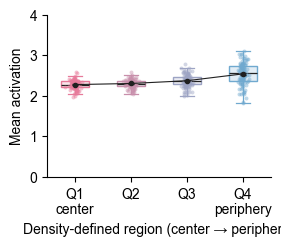

In [ ]:
RANDOM_STATE = 2026
fig, ax = plot_density_region_metric(
    "mean_activation",
    annotate_page=False
)

savefig_to_dir(
    fig,
    FIG_DIR,
    PLOT_INFO[
        "mean_activation"
    ]["filename"]
)

plt.show()


fig, ax = plot_density_region_metric(
    "top2_margin",
    annotate_page=False
)

savefig_to_dir(
    fig,
    FIG_DIR,
    PLOT_INFO[
        "top2_margin"
    ]["filename"]
)

plt.show()


fig, ax = plot_density_region_metric(
    "speed_pc_per_s",
    annotate_page=False
)

savefig_to_dir(
    fig,
    FIG_DIR,
    PLOT_INFO[
        "speed_pc_per_s"
    ]["filename"]
)

plt.show()

